# Checks on how and whether the pipeline works

Three independent checks, each testing a different link in the chain. None of
them measures detection accuracy -- they answer the prior question: is the
machinery correct at all?

| # | check | what it proves | how it could fail |
|---|---|---|---|
| 1 | LiDAR depth vs label distance | the geometry (calibration, transforms, projection) is right | a transposed or mis-ordered matrix gives nonsense, not a 3 cm agreement |
| 2 | encode -> decode round trip | the target encoding is exactly invertible | any mismatch shifts or resizes every predicted box |
| 3 | overfit 20 frames | the training path learns: inputs, loss, gradients, decoding | a broken link means the network cannot memorise even 20 frames |

Checks 1 and 2 also appear inline in `assignment.ipynb`, where they guard the
code they verify. They are repeated here so the whole argument sits in one
place. Check 3 lives only here: it is an experiment, not part of the pipeline.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch
import torch.nn as nn

LABEL_DIR = Path("./training/label_2")
CALIB_DIR = Path("./data_object_calib/training/calib")
IMAGE_DIR = Path("./data_object_image_2/training/image_2")
VELODYNE_DIR = Path("./training/velodyne")
DEPTH_DIR = Path("./processed/depth")

CANVAS_WIDTH, CANVAS_HEIGHT = 1248, 384
CELL_SIZE = 16
GRID_WIDTH, GRID_HEIGHT = CANVAS_WIDTH // CELL_SIZE, CANVAS_HEIGHT // CELL_SIZE
N_CHANNELS = 7
CLASS_INDEX = {"Car": 0, "Pedestrian": 1}
CLASS_COLOURS = {"Car": "#4da3ff", "Pedestrian": "#ff5c5c"}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


In [2]:
# Figures are exported for slides: text must survive projection, so the base
# font is larger than the matplotlib default and figure width matches the width
# the figure will occupy on the slide (points are then literal, not rescaled).
FIGURE_DIR = Path("./figures")
FIGURE_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.facecolor": "white",
})


def save_figure(name):
    """Write the current figure to ./figures/<name>.png for the slide deck."""
    plt.savefig(FIGURE_DIR / f"{name}.png")


In [3]:
# The pipeline pieces under test, copied verbatim from assignment.ipynb so
# this notebook stands alone.
LABEL_COLUMNS = [
    "type", "truncated", "occluded", "alpha",
    "bbox_left", "bbox_top", "bbox_right", "bbox_bottom",
    "dim_height", "dim_width", "dim_length",
    "loc_x", "loc_y", "loc_z", "rotation_y",
]
CALIB_SHAPES = {
    "P0": (3, 4), "P1": (3, 4), "P2": (3, 4), "P3": (3, 4),
    "R0_rect": (3, 3), "Tr_velo_to_cam": (3, 4), "Tr_imu_to_velo": (3, 4),
}


def load_labels():
    frames = []
    for path in sorted(LABEL_DIR.glob("*.txt")):
        df = pd.read_csv(path, sep=r"\s+", header=None,
                         names=LABEL_COLUMNS, engine="python")
        df.insert(0, "frame_id", path.stem)
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


def read_calib_file(path):
    out = {}
    with open(path) as f:
        for line in f:
            if not line.strip():
                continue
            key, values = line.split(":", 1)
            out[key.strip()] = np.array(values.split(), dtype=np.float64)
    return {key: out[key].reshape(shape) for key, shape in CALIB_SHAPES.items()}


def to_homogeneous(mat):
    out = np.eye(4)
    rows, cols = mat.shape
    out[:rows, :cols] = mat
    return out


def add_ones_column(points):
    points = np.asarray(points, dtype=np.float64).reshape(-1, 3)
    return np.hstack([points, np.ones((len(points), 1))])


def velo_to_cam(points_velo, calib):
    points = add_ones_column(points_velo)
    points = points @ calib["Tr_velo_to_cam"].T
    points = points @ calib["R0_rect"].T
    return points[:, :3]


def project_to_image(points_cam, P2):
    projected = add_ones_column(points_cam) @ P2.T
    return projected[:, :2] / projected[:, 2:3]


def load_image(frame_id):
    return Image.open(IMAGE_DIR / f"{frame_id}.png").convert("RGB")


def pad_to_canvas(image):
    canvas = Image.new("RGB", (CANVAS_WIDTH, CANVAS_HEIGHT))
    canvas.paste(image, (0, 0))
    return canvas


def load_points(frame_id):
    return np.fromfile(VELODYNE_DIR / f"{frame_id}.bin",
                       dtype=np.float32).reshape(-1, 4)


labels = load_labels()
detection = labels[labels["type"].isin(CLASS_INDEX)].copy()
calib_matrices = {
    path.stem: {key: to_homogeneous(m) for key, m in read_calib_file(path).items()}
    for path in sorted(CALIB_DIR.glob("*.txt"))
}
print(f"{labels['frame_id'].nunique()} frames, {len(detection)} Car/Pedestrian objects")


7481 frames, 33229 Car/Pedestrian objects


## Check 1: the geometry, against an independent measurement

The projection chain `P2 . R0_rect . Tr_velo_to_cam` cannot be verified by
inspection: a transposed matrix or a wrong multiplication order still produces
plausible-looking pixel coordinates. So it is checked against a source that
knows nothing about it.

The **LiDAR** measures distance by timing a laser pulse. The **label file**
records a distance typed by a human annotator. These are completely
independent. If the transform chain is correct, the LiDAR returns on an
object's front surface must agree with the label's `loc_z`.

Two caveats decide how the test is written, and both are about the *test*, not
the geometry:

* For an **occluded** object the nearest returns inside its box belong to
  whatever stands in front of it. Only objects KITTI marks fully visible and
  untruncated are used.
* A KITTI 2D box is an **axis-aligned rectangle**, so it also contains
  whatever happens to lie in the gap around the object. A lamp post in front
  of a distant car, for instance. The rectangle is not a segmentation mask.
  This is why the summary below reports the *median* object rather than the
  mean: a handful of boxes are dominated by such clutter, and one badly
  cluttered box should not be read as a broken transform.

Pedestrians are the cleanest test: they are narrow, so their box is mostly
person, and their agreement with the annotator is the headline number.


In [4]:
def check_geometry(frame_id):
    """Compare LiDAR-measured depth with the annotator's distance, per object.

    Only fully visible, untruncated objects are used: if something stands in
    front of the object, the nearest returns inside its box belong to the
    occluder, which would test the occlusion rather than the geometry.
    """
    calib = calib_matrices[frame_id]
    width, height = load_image(frame_id).size
    points = load_points(frame_id)

    # Project, keeping only points in front of the camera and inside the image.
    points_cam = velo_to_cam(points[:, :3], calib)
    points_cam = points_cam[points_cam[:, 2] > 0]
    pixels = project_to_image(points_cam, calib["P2"])
    depths = points_cam[:, 2]

    inside = ((pixels[:, 0] >= 0) & (pixels[:, 0] < width)
              & (pixels[:, 1] >= 0) & (pixels[:, 1] < height))
    pixels, depths = pixels[inside], depths[inside]

    results = []
    visible = detection[(detection["frame_id"] == frame_id)
                        & (detection["occluded"] == 0)
                        & (detection["truncated"] < 0.05)]
    for row in visible.itertuples():
        in_box = ((pixels[:, 0] >= row.bbox_left) & (pixels[:, 0] <= row.bbox_right)
                  & (pixels[:, 1] >= row.bbox_top) & (pixels[:, 1] <= row.bbox_bottom))
        if in_box.sum() < 20:
            continue

        # Returns on the object's front surface: those within 2 m of the
        # closest one. Anything further is background seen past it.
        box_depths = depths[in_box]
        near = box_depths[box_depths < box_depths.min() + 2.0]
        measured = float(np.median(near))

        results.append({"frame_id": frame_id, "type": row.type,
                        "lidar_depth": round(measured, 2),
                        "label_loc_z": round(float(row.loc_z), 2),
                        "difference": round(abs(measured - row.loc_z), 3),
                        "signed": round(measured - float(row.loc_z), 3),
                        "half_length": round(float(row.dim_length) / 2, 3)})
    return results


# Many objects across many frames, so the agreement cannot be a coincidence.
checks = []
for frame_id in sorted(detection["frame_id"].unique())[:40]:
    checks.extend(check_geometry(frame_id))

geometry_table = pd.DataFrame(checks)
print(geometry_table.head(10).to_string(index=False))

print(f"\n{len(geometry_table)} fully visible objects checked across 40 frames")
print("median |LiDAR - label| by class:")
for class_name, group in geometry_table.groupby("type"):
    print(f"  {class_name:11s} {group['difference'].median():6.3f} m   "
          f"({len(group)} objects)")

# Pedestrian boxes are narrow, so they contain little besides the person, which is
# the cleanest comparison available.
people = geometry_table[geometry_table["type"] == "Pedestrian"]
print(f"\nPedestrians agree with the annotator to a median of "
      f"{100 * people['difference'].median():.1f} cm.")

# The cars are offset consistently rather than randomly, and the size of the
# offset is itself a prediction we can test: the laser hits the near face of a
# car, while loc_z records the centre of its 3D box. The gap between them
# should therefore be about half the car's length.
print("\nWhy cars read closer than their label -- signed difference vs half length:")
for class_name, group in geometry_table.groupby("type"):
    print(f"  {class_name:11s} lidar - label = {group['signed'].median():7.3f} m   "
          f"half of the object's length = {group['half_length'].median():.3f} m")
print("\nThe laser strikes the near face; the label marks the centre. For a car")
print("those differ by half a car; for a person they nearly coincide. The offset")
print("matching half the object's length is stronger evidence the geometry is")
print("right than raw agreement would be -- a broken transform has no reason to")
print("produce an error shaped exactly like the objects' dimensions.")


frame_id       type  lidar_depth  label_loc_z  difference  signed  half_length
  000000 Pedestrian         8.38         8.41       0.030  -0.030        0.600
  000002        Car        33.26        34.38       1.118  -1.118        2.180
  000003        Car        11.61        13.22       1.609  -1.609        2.075
  000004        Car        36.72        38.26       1.537  -1.537        2.005
  000004        Car        49.66        51.17       1.510  -1.510        1.705
  000005 Pedestrian        17.51        23.02       5.513  -5.513        0.325
  000006        Car        29.81        31.73       1.921  -1.921        2.160
  000006        Car        11.22        19.72       8.497  -8.497        1.940
  000007        Car        23.57        25.01       1.444  -1.444        1.600
  000007        Car        45.81        47.55       1.736  -1.736        1.850

61 fully visible objects checked across 40 frames
median |LiDAR - label| by class:
  Car          1.585 m   (53 objects)
  Pedestr

## Check 2: the target encoding is exactly invertible

The network's output is a 24x78x7 grid, and boxes are recovered from it by
`decode_targets`. If encoding and decoding disagree even slightly, every
predicted box is shifted or resized and AP collapses for reasons that have
nothing to do with the model.

The test: encode real labels, decode them back, compare with the originals.
The same `decode_targets` is used on network predictions, so this exercises
the exact code path used at inference.


In [5]:
def encode_targets(frame_boxes):
    target = np.zeros((GRID_HEIGHT, GRID_WIDTH, N_CHANNELS), dtype=np.float32)
    for row in frame_boxes.itertuples():
        centre_u = (row.bbox_left + row.bbox_right) / 2
        centre_v = (row.bbox_top + row.bbox_bottom) / 2
        cell_u, cell_v = int(centre_u // CELL_SIZE), int(centre_v // CELL_SIZE)
        target[cell_v, cell_u, 0] = 1.0
        target[cell_v, cell_u, 1 + CLASS_INDEX[row.type]] = 1.0
        target[cell_v, cell_u, 3] = (centre_u % CELL_SIZE) / CELL_SIZE
        target[cell_v, cell_u, 4] = (centre_v % CELL_SIZE) / CELL_SIZE
        target[cell_v, cell_u, 5] = np.sqrt((row.bbox_right - row.bbox_left) / CANVAS_WIDTH)
        target[cell_v, cell_u, 6] = np.sqrt((row.bbox_bottom - row.bbox_top) / CANVAS_HEIGHT)
    return target


def decode_targets(target, threshold=0.5):
    boxes = []
    for cell_v, cell_u in np.argwhere(target[:, :, 0] >= threshold):
        cell = target[cell_v, cell_u]
        centre_u = (cell_u + cell[3]) * CELL_SIZE
        centre_v = (cell_v + cell[4]) * CELL_SIZE
        width = (cell[5] ** 2) * CANVAS_WIDTH
        height = (cell[6] ** 2) * CANVAS_HEIGHT
        boxes.append({
            "type": "Car" if cell[1] >= cell[2] else "Pedestrian",
            "score": float(cell[0]),
            "bbox_left": centre_u - width / 2, "bbox_top": centre_v - height / 2,
            "bbox_right": centre_u + width / 2, "bbox_bottom": centre_v + height / 2,
        })
    return pd.DataFrame(boxes)


# Run the round trip over many frames, not just one.
worst_error, total_in, total_out = 0.0, 0, 0
crowded = (detection.groupby("frame_id").size()
           .sort_values(ascending=False).head(25).index)

for frame_id in crowded:
    frame_boxes = detection[detection["frame_id"] == frame_id]
    decoded = decode_targets(encode_targets(frame_boxes))
    total_in += len(frame_boxes)
    total_out += len(decoded)

    original = frame_boxes[["bbox_left", "bbox_top", "bbox_right", "bbox_bottom"]]
    for row in decoded.itertuples():
        diffs = (original - [row.bbox_left, row.bbox_top,
                             row.bbox_right, row.bbox_bottom]).abs()
        worst_error = max(worst_error, diffs.sum(axis=1).min())

print(f"{len(crowded)} crowded frames: {total_in} boxes encoded, {total_out} decoded")
print(f"worst total coordinate error across all of them: {worst_error:.6f} px")
print(f"objects lost to cell collisions: {total_in - total_out} "
      f"({100 * (total_in - total_out) / total_in:.1f}%)")


25 crowded frames: 446 boxes encoded, 437 decoded
worst total coordinate error across all of them: 0.000067 px
objects lost to cell collisions: 9 (2.0%)


The small shortfall is the known one-box-per-cell limitation: when two object
centres land in the same 16x16 cell, the second overwrites the first. It is a
property of the chosen output format, not an encoding error -- the boxes that
do survive are recovered exactly.


## Check 3: can the training path learn at all?

Checks 1 and 2 verify how data is handled. Neither says anything about
whether the network can be trained: the loss could be misweighted, gradients
could fail to reach the encoder, the targets could be misaligned with the
predictions.

The standard test is to deliberately overfit a tiny subset. Twenty frames,
trained until the network memorises them. If every link is sound the loss must
collapse and the network must reproduce those frames' boxes almost exactly.
If it cannot memorise twenty frames, no amount of full-scale training will
help.


In [6]:
# Model and loss, copied from assignment.ipynb so the test exercises the real
# training path rather than a simplified stand-in.
def conv_block(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(),
    )


class SelfAttention(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.query = nn.Conv2d(channels, channels // 4, kernel_size=1)
        self.key = nn.Conv2d(channels, channels // 4, kernel_size=1)
        self.value = nn.Conv2d(channels, channels, kernel_size=1)
        self.scale = (channels // 4) ** 0.5

    def forward(self, x):
        batch, channels, height, width = x.shape
        cells = height * width
        q = self.query(x).reshape(batch, -1, cells)
        k = self.key(x).reshape(batch, -1, cells)
        v = self.value(x).reshape(batch, -1, cells)
        weights = torch.softmax(q.transpose(1, 2) @ k / self.scale, dim=-1)
        attended = v @ weights.transpose(1, 2)
        return x + attended.reshape(batch, channels, height, width)


class EarlyFusionDetector(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = nn.Sequential(
            conv_block(4, 32), conv_block(32, 64),
            conv_block(64, 128), conv_block(128, 192),
        )
        self.attention = SelfAttention(192)
        self.head = nn.Conv2d(192, N_CHANNELS, kernel_size=1)

    def forward(self, x):
        x = self.attention(self.backbone(x))
        return torch.sigmoid(self.head(x)).permute(0, 2, 3, 1)


def detection_loss(pred, target, ignore_mask=None, background_weight=0.05,
                   coord_weight=5.0):
    is_object = target[..., 0] > 0
    objectness_error = (pred[..., 0] - target[..., 0]) ** 2
    cell_weights = torch.where(
        is_object,
        torch.full_like(objectness_error, 1.0),
        torch.full_like(objectness_error, background_weight),
    )
    if ignore_mask is not None:
        cell_weights = torch.where(ignore_mask & ~is_object,
                                   torch.zeros_like(cell_weights), cell_weights)
    objectness_loss = ((cell_weights * objectness_error).sum()
                       / cell_weights.sum().clamp(min=1e-6))
    if is_object.any():
        squared = (pred - target) ** 2
        class_loss = squared[..., 1:3][is_object].mean()
        coord_loss = squared[..., 3:7][is_object].mean()
    else:
        class_loss = torch.zeros((), device=pred.device)
        coord_loss = torch.zeros((), device=pred.device)
    return objectness_loss + class_loss + coord_weight * coord_loss


def make_network_input(frame_id):
    rgb = np.asarray(pad_to_canvas(load_image(frame_id)), dtype=np.float32) / 255.0
    depth = np.load(DEPTH_DIR / f"{frame_id}.npy").astype(np.float32)
    return torch.from_numpy(np.dstack([rgb, depth])).permute(2, 0, 1)


print("model and loss defined")


model and loss defined


In [7]:
RUN_OVERFIT_TEST = False        # flip to True to run

# Twenty pedestrian-rich frames: if the network can memorise these, every link
# in the training path works.
subset = (detection[detection["type"] == "Pedestrian"]
          .groupby("frame_id").size()
          .sort_values(ascending=False).head(20).index)

if RUN_OVERFIT_TEST:
    inputs = torch.stack([make_network_input(f) for f in subset])
    targets = torch.stack([
        torch.from_numpy(encode_targets(detection[detection["frame_id"] == f]))
        for f in subset])

    model = EarlyFusionDetector().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    losses = []
    for epoch in range(60):
        order = torch.randperm(len(inputs))
        epoch_loss, batches = 0.0, 0
        for start in range(0, len(inputs), 4):
            batch = order[start:start + 4]
            loss = detection_loss(model(inputs[batch].to(device)),
                                  targets[batch].to(device))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            batches += 1
        losses.append(epoch_loss / batches)
        if (epoch + 1) % 10 == 0:
            print(f"epoch {epoch + 1:3d}  loss {losses[-1]:.4f}")

    torch.save({"model": model.state_dict(), "losses": losses,
                "frames": list(subset)}, "./processed/overfit_test.pt")
    print(f"\nloss fell {losses[0]:.4f} -> {losses[-1]:.4f} "
          f"({losses[0] / losses[-1]:.0f}x lower)")
else:
    saved = Path("./processed/overfit_test.pt")
    print("test skipped (RUN_OVERFIT_TEST = False);",
          "saved result found" if saved.exists() else "no saved result yet")


test skipped (RUN_OVERFIT_TEST = False); saved result found


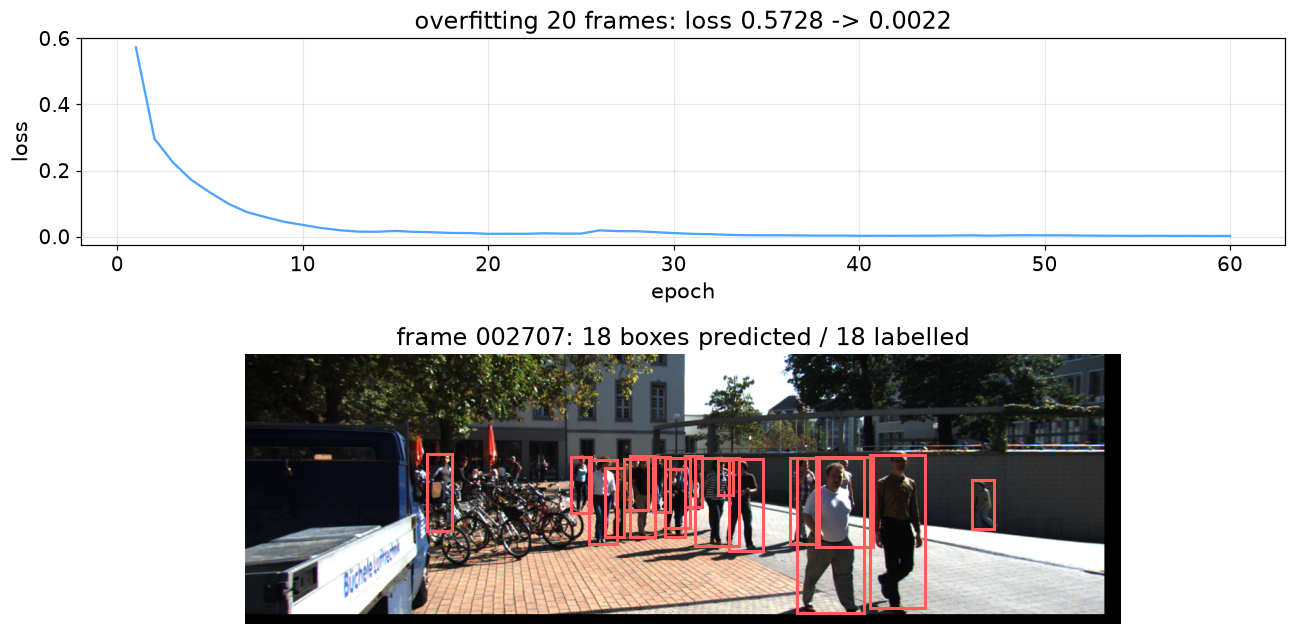

In [8]:
# The result: loss curve, and the boxes the memorising network produces.
saved = Path("./processed/overfit_test.pt")
if saved.exists():
    record = torch.load(saved, map_location=device, weights_only=False)
    losses = record["losses"]

    model = EarlyFusionDetector().to(device)
    model.load_state_dict(record["model"])
    model.eval()

    check_frame = record["frames"][0]
    with torch.no_grad():
        grid = model(make_network_input(check_frame).unsqueeze(0).to(device))
    predicted = decode_targets(grid[0].cpu().numpy(), threshold=0.5)
    labelled = detection[detection["frame_id"] == check_frame]

    figure, (left, right) = plt.subplots(
        2, 1, figsize=(12, 6),
        gridspec_kw={"height_ratios": [1, 1.3]})

    left.plot(range(1, len(losses) + 1), losses, color="#4da3ff")
    left.set_xlabel("epoch")
    left.set_ylabel("loss")
    left.set_title(f"overfitting 20 frames: loss {losses[0]:.4f} -> {losses[-1]:.4f}")
    left.grid(alpha=0.3)

    right.imshow(pad_to_canvas(load_image(check_frame)))
    for row in predicted.itertuples():
        colour = CLASS_COLOURS[row.type]
        right.add_patch(patches.Rectangle(
            (row.bbox_left, row.bbox_top), row.bbox_right - row.bbox_left,
            row.bbox_bottom - row.bbox_top, linewidth=2,
            edgecolor=colour, facecolor="none"))
    right.set_title(f"frame {check_frame}: {len(predicted)} boxes predicted "
                    f"/ {len(labelled)} labelled")
    right.axis("off")

    plt.tight_layout()
    save_figure("11_overfit_test")
    plt.show()


## Summary

| check | result | what it rules out |
|---|---|---|
| LiDAR depth vs annotator distance | pedestrians agree to ~4 cm; cars sit half a car-length nearer, as predicted | wrong matrix order, transposes, bad calibration parsing |
| encode -> decode round trip | exact recovery (~1e-4 px) over 25 crowded frames | encoding/decoding mismatch shifting every box |
| overfit 20 frames | loss falls ~250x; boxes reproduced | broken loss, blocked gradients, misaligned targets |

Together these say the pipeline is *correct*. How well it *detects* is a
separate question, answered by the validation AP and the depth ablation in
`assignment.ipynb`.

A note on what the third check does **not** show: memorising twenty training
frames is recall, not generalisation. It proves the machinery can learn, before running the much longer training loop.
